---
<a id='ejercicio'></a>

Alumna: Sandra Geraldine Castillo Dorantes

## Sesion 9 - Ejercicio Integrador

Usando la tabla maestra que construimos hoy:

**1.** Con `pipe()` construye un pipeline de 3 pasos:
solo polizas activas → agregar columna `loss_ratio` → filtrar `loss_ratio > 0`

**2.** Usa `query()` para encontrar las pólizas GMM con `nivel_riesgo >= 'MEDIO'`
y `prima_total > 5000`. ¿Cuántas son? ¿Cuál es su prima promedio?

**3.** Con `crosstab()` calcula el porcentaje de pólizas en nivel ALTO por estado.
¿Cuál estado tiene mayor % de riesgo alto?

**4.** Crea una figura con 2 subgráficas lado a lado:
- Izquierda: barras con prima promedio por `nivel_riesgo` (usa los 3 niveles ordenados)
- Derecha: barras con número de pólizas por `cuartil_prima`

======== 1. CONSTRUCCION DE UN PIPELINE ==========

Polizas totales: 50,000 → Polizas activas 45,074
*Se ha creado la columna loss_ratio
Quedan 5,549 polizas con loss_ratio > 0

Resultado:
Pipeline con 5,549 registros y 52 columnas 

============ 2. USAR QUERY() ============
Polizas de gastos medicos con nivel_riesgo >= MEDIO y prima_total > 5000:
6,845 polizas
Prima promedio $31,957.34

============= 3. USAR CROSSTAB() =============

Distribucion % riesgo ALTO por estado:

estado
Baja California     4.69
CDMX                5.00
Chihuahua           5.55
Coahuila            5.47
Estado de Mexico    5.66
Guanajuato          5.14
Jalisco             5.01
Michoacan           5.25
Nuevo Leon          5.52
Puebla              5.12
Queretaro           5.02
Sonora              5.38
Tamaulipas          4.55
Veracruz            5.12
Yucatan             5.15
Name: ALTO, dtype: float64

Estado con mayor riesgo ALTO: Estado de Mexico (5.66 %)

============= 4. GRAFICOS FINALES =============


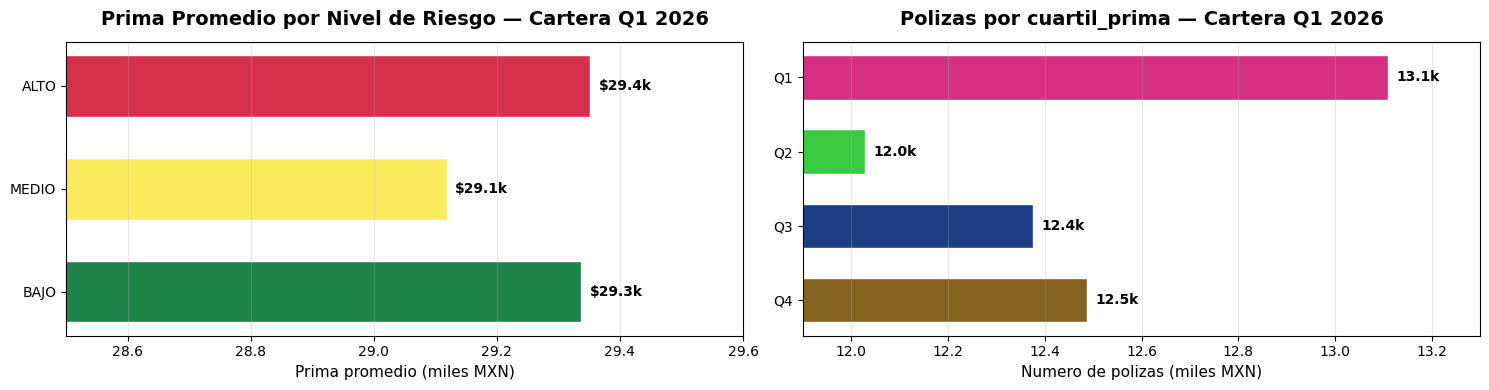

In [1]:
# ------ Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importar parquet construido en la sesion 9
ruta = 'C:/Users/HP/Diplomado-ML-Geraldine-Castillo/Modulo_1'
df = pd.read_parquet(ruta + '/datos/cartera_q1_2026_final(sesion_9).parquet')

# ==========================================
# ======== 1. CONSTRUIR UN PIPELINE ========

print("======== 1. CONSTRUCCION DE UN PIPELINE ==========")
print()

# Definimos las funciones que usaremos
def activas(df):
    n = len(df)
    df = df[df['status_poliza'] == 'Vigente']
    print(f"Polizas totales: {n:,} → Polizas activas {len(df):,}")
    return df

def loss_ratio(df):
    df = df.assign(
        loss_ratio = lambda x: (x['monto_pagado'] / x['prima_total']).clip(0, 5)
    )
    print("*Se ha creado la columna loss_ratio")
    return df

def filtro_loss_ratio(df):
    df = df[df['loss_ratio'] > 0]
    print(f"Quedan {len(df):,} polizas con loss_ratio > 0")
    return df

df_pipe = (
    df
    .pipe(activas)
    .pipe(loss_ratio)
    .pipe(filtro_loss_ratio)
)
print()
print(f'Resultado:')
print(f"Pipeline con {df_pipe.shape[0]:,} registros y {df_pipe.shape[1]} columnas ")
print()

# =======================================
# =========== 2. USAR QUERY() ===========

print("============ 2. USAR QUERY() ============")

df_filtrado = df.query('ramo == "GMM" and nivel_riesgo >= "MEDIO" and prima_total > 5000')
print("Polizas de gastos medicos con nivel_riesgo >= MEDIO y prima_total > 5000:")
print(f"{len(df_filtrado):,} polizas")
print(f"Prima promedio ${df_filtrado['prima_total'].mean().round(2):,.2f}")
print()

# =====================================
# =========== 3. CROSSTAB() ===========

print("============= 3. USAR CROSSTAB() =============")
print()

estado_pct = pd.crosstab(df['estado'],
                       df['nivel_riesgo'],
                       normalize='index').mul(100).round(2)
altos = estado_pct['ALTO']
print('Distribucion % riesgo ALTO por estado:')
print()
print(altos)
print()
print(f"Estado con mayor riesgo ALTO: {altos.idxmax()} ({altos.max()} %)")
print()

# ==================================
# =========== 4. GRAFICO ===========
print("============= 4. GRAFICOS FINALES =============")
# print()

df_promedio = df.groupby('nivel_riesgo', observed=False)['prima_total'].mean()
df_cuartil = df.groupby('cuartil_prima', observed=False)['id_poliza'].count().sort_index(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=False)

# ------ PRIMER GRAFICO -------

COLORES_1 = {'ALTO':"#D6304B",'MEDIO':"#FCEC5D", 'BAJO':'#1E8449'}
colores_barras_1 = [COLORES_1.get(r, '#888888') for r in df_promedio.index]

bars = axes[0].barh(df_promedio.index, df_promedio.values / 1_000,
               color=colores_barras_1, height=0.6, edgecolor='white')

axes[0].bar_label(bars, fmt='$%.1fk', padding=6, fontsize=10, fontweight='bold')
axes[0].set_xlabel('Prima promedio (miles MXN)', fontsize=11)
axes[0].set_title('Prima Promedio por Nivel de Riesgo — Cartera Q1 2026',
              fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlim(28.5, 29.6)
axes[0].grid(axis='x', alpha=0.3)

# ------ SEGUNDO GRAFICO -------

COLORES_2 = {'Q1':"#D63083",'Q2':"#3CCA43", 'Q3':"#1E3E84", 'Q4':"#84641E"}
colores_barras_2 = [COLORES_2.get(r, '#888888') for r in df_cuartil.index]

bars = axes[1].barh(df_cuartil.index, df_cuartil.values/1_000,
               color=colores_barras_2, height=0.6, edgecolor='white')

axes[1].bar_label(bars, fmt='%.1fk', padding=6, fontsize=10, fontweight='bold')
axes[1].set_xlabel('Numero de polizas (miles MXN)', fontsize=11)
axes[1].set_title('Polizas por cuartil_prima — Cartera Q1 2026',
              fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlim(11.9, 13.3)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()